In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 


In [38]:
# Data Loading
df = pd.read_csv(r"C:\Users\Sneha Srishti\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\75951FFFB5B7F0012E6614D8414F20FA786CDB87\transfers\2026-11\housing.csv")
print("Task 1.1 — First few rows:")
print(df.head())
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
 

Task 1.1 — First few rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
Shape: 20640 rows, 10 columns


In [15]:
print("Task 1.2 — Data types:")
print(df.dtypes)
 
print("Missing values per column:")
print(df.isnull().sum())
print(f"Columns with missing data: {df.columns[df.isnull().any()].tolist()}")

Task 1.2 — Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Columns with missing data: ['total_bedrooms']


In [16]:
print("Task 2.1 — Summary Statistics:")
print(df.describe())

Task 2.1 — Summary Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0

Correlation with median_house_value (sorted):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


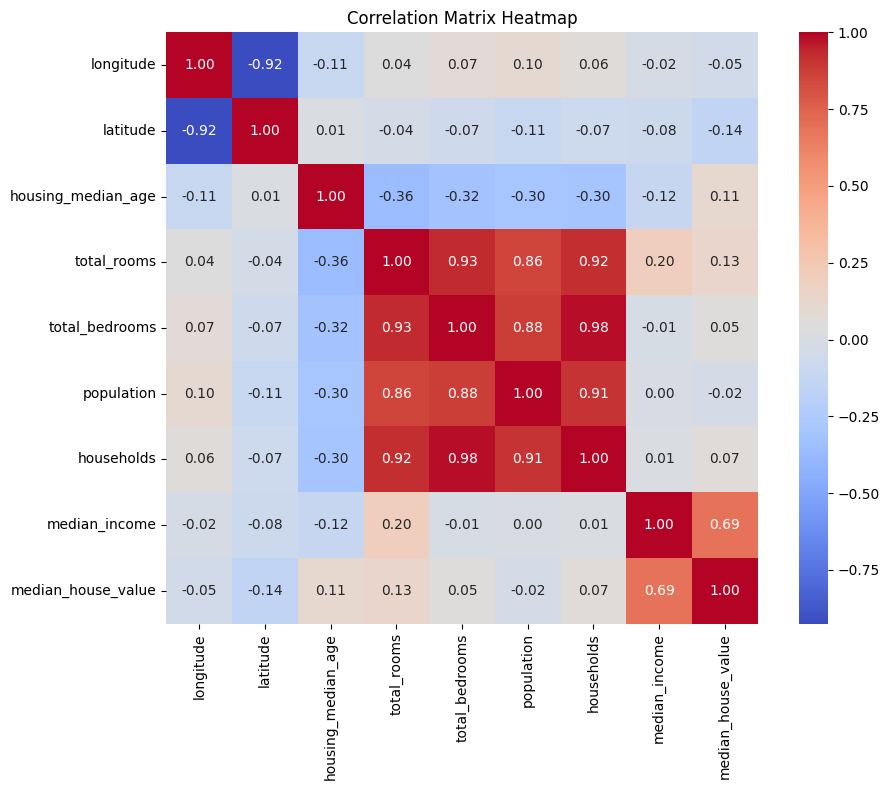

In [39]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
print("Correlation with median_house_value (sorted):")
print(corr_matrix["median_house_value"].sort_values(ascending=False))
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

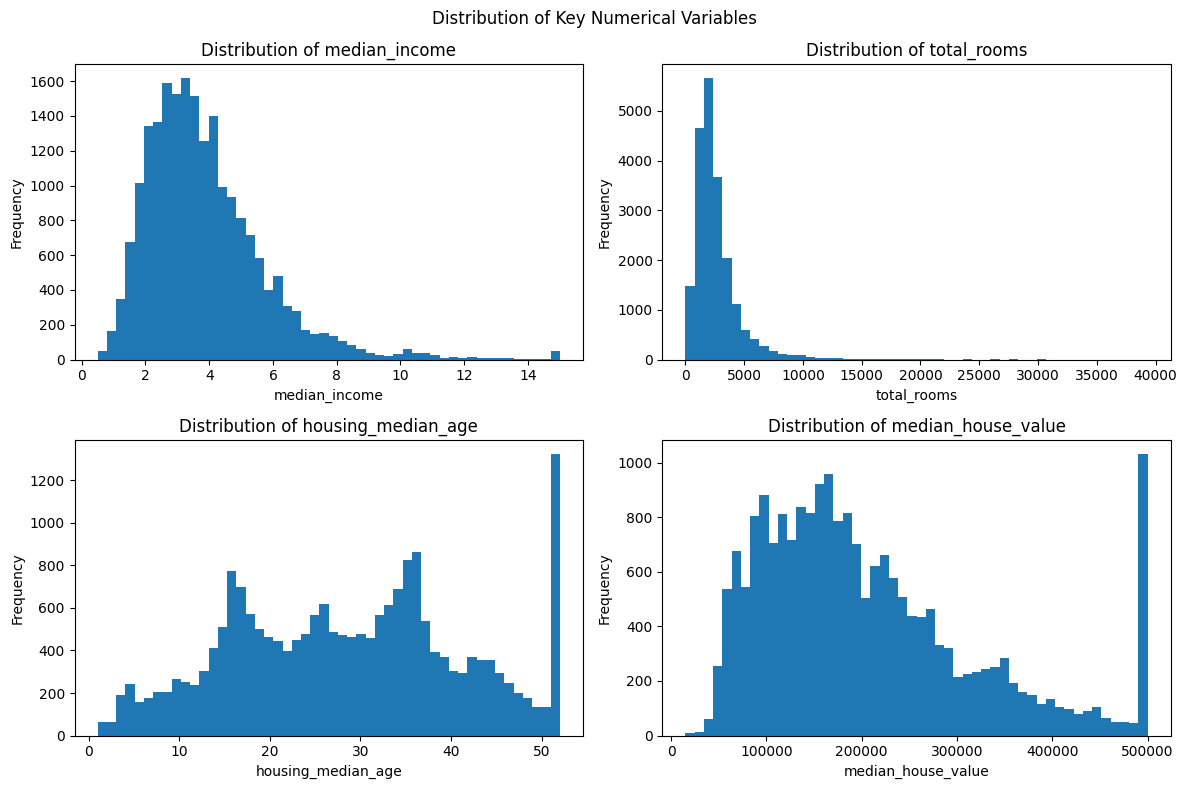

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ["median_income", "total_rooms", "housing_median_age", "median_house_value"]
 
for ax, col in zip(axes.flatten(), cols):
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
 
plt.suptitle("Distribution of Key Numerical Variables")
plt.tight_layout()
plt.show()

 

Value counts for ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Average house price by ocean proximity:
ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64


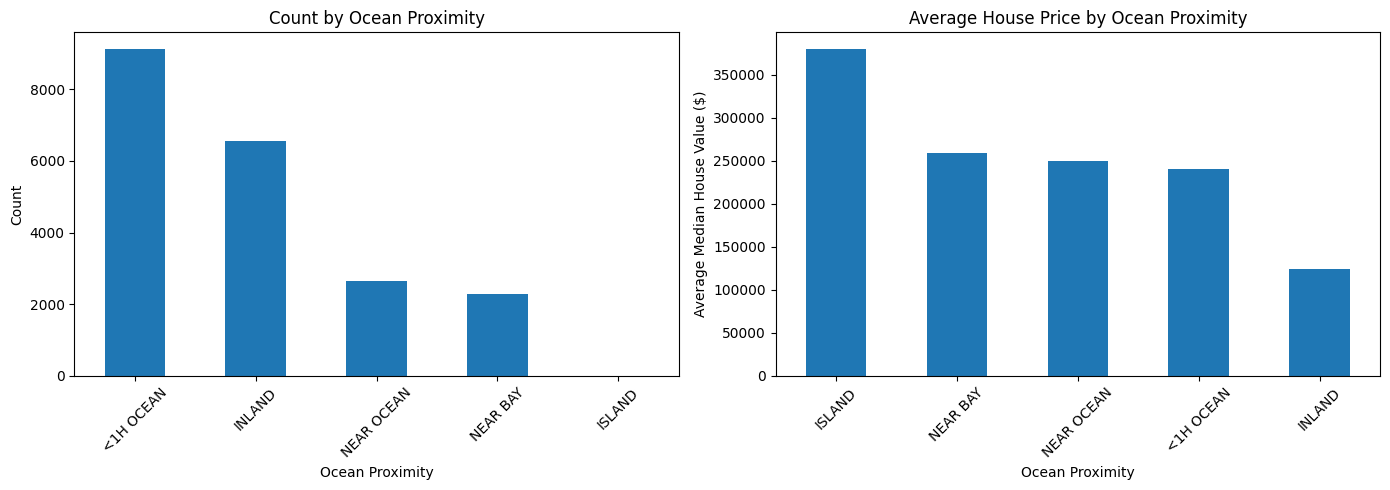

In [41]:
print("Value counts for ocean_proximity:")
print(df["ocean_proximity"].value_counts())
 
print("\nAverage house price by ocean proximity:")
avg_price = df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False)
print(avg_price)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
df["ocean_proximity"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Count by Ocean Proximity")
axes[0].set_xlabel("Ocean Proximity")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
 
avg_price.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average House Price by Ocean Proximity")
axes[1].set_xlabel("Ocean Proximity")
axes[1].set_ylabel("Average Median House Value ($)")
axes[1].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()

In [19]:
print(f"Task 3.1 — Missing in total_bedrooms: {df['total_bedrooms'].isnull().sum()}")
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
print(f"After filling: {df['total_bedrooms'].isnull().sum()} missing values")

Task 3.1 — Missing in total_bedrooms: 207
After filling: 0 missing values


In [43]:
df = pd.get_dummies(df, columns=["ocean_proximity"])
 
print(f"Shape after encoding: {df.shape}")
display(df.head(3))

Shape after encoding: (20640, 14)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False


In [21]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
print(f"Task 3.3 — Features shape: {X.shape}, Target shape: {y.shape}")

Task 3.3 — Features shape: (20640, 13), Target shape: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Task 3.4 — Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
 
# Task 3.5 — Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 16512
Testing set size : 4128


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Task 4.2 — Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)



In [47]:
# Task 4.3 — Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)


--- Linear Regression ---
MAE  : 50670.74
MSE  : 4908476721.16
RMSE : 70060.52
R²   : 0.6254

--- Decision Tree ---
MAE  : 43550.40
MSE  : 4771875804.93
RMSE : 69078.77
R²   : 0.6358

--- Random Forest ---
MAE  : 31628.59
MSE  : 2395314930.14
RMSE : 48941.95
R²   : 0.8172
Model Comparison Table:


,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,50670.74,4.908477e+09,70060.52,0.6254
Decision Tree,43550.40,4.771876e+09,69078.77,0.6358
Random Forest,31628.59,2.395315e+09,48941.95,0.8172



Best performing model: Random Forest (R² = 0.8172)


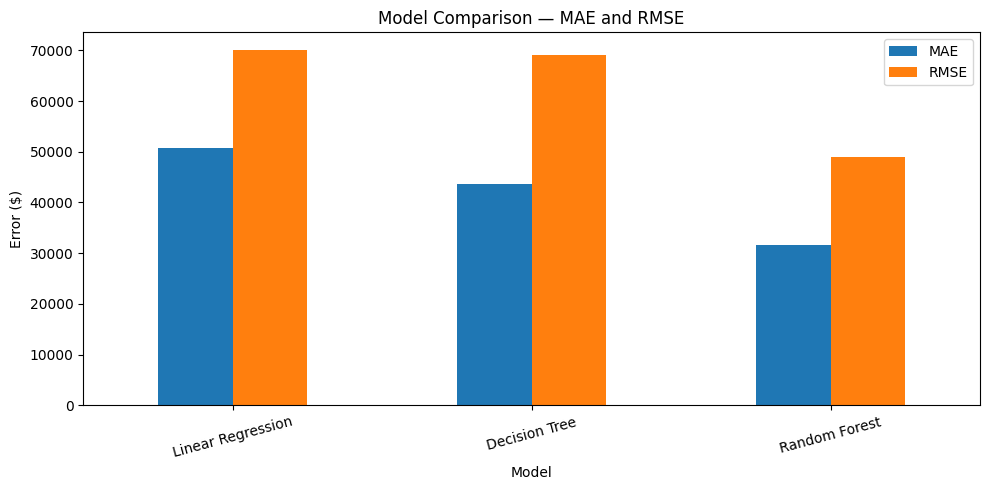

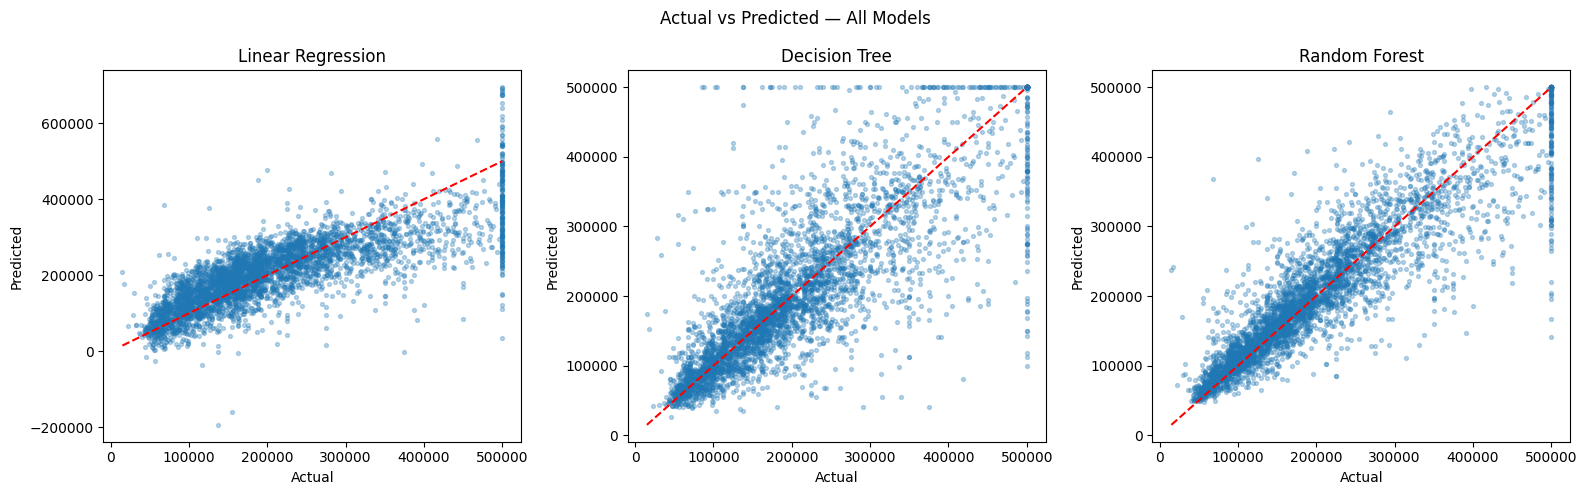

In [45]:
#Task 5.1
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    return {"Model": name, "MAE": round(mae,2), "MSE": round(mse,2), "RMSE": round(rmse,2), "R2": round(r2,4)}
 
r1 = evaluate_model("Linear Regression", y_test, y_pred_lr)
r2_ = evaluate_model("Decision Tree",    y_test, y_pred_dt)
r3 = evaluate_model("Random Forest",     y_test, y_pred_rf)
 
 # Task 5.2 — Compare all models and identify the best

results_df = pd.DataFrame([r1, r2_, r3]).set_index("Model")
 
print("Model Comparison Table:")
display(results_df)
 
best_model = results_df["R2"].idxmax()
print(f"\nBest performing model: {best_model} (R² = {results_df.loc[best_model, 'R2']})")
 
# Bar chart comparison
results_df[["MAE", "RMSE"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison — MAE and RMSE")
plt.ylabel("Error ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
 
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, preds) in zip(axes, [("Linear Regression", y_pred_lr),
                                     ("Decision Tree",     y_pred_dt),
                                     ("Random Forest",     y_pred_rf)]):
    ax.scatter(y_test, preds, alpha=0.3, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.5)
    ax.set_title(f"{name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
 
plt.suptitle("Actual vs Predicted — All Models")
plt.tight_layout()
plt.show()
 
 

Top 10 Feature Importances:
median_income                 0.4906
ocean_proximity_INLAND        0.1409
longitude                     0.1059
latitude                      0.1016
housing_median_age            0.0519
population                    0.0326
total_bedrooms                0.0238
total_rooms                   0.0234
households                    0.0184
ocean_proximity_NEAR OCEAN    0.0063
dtype: float64


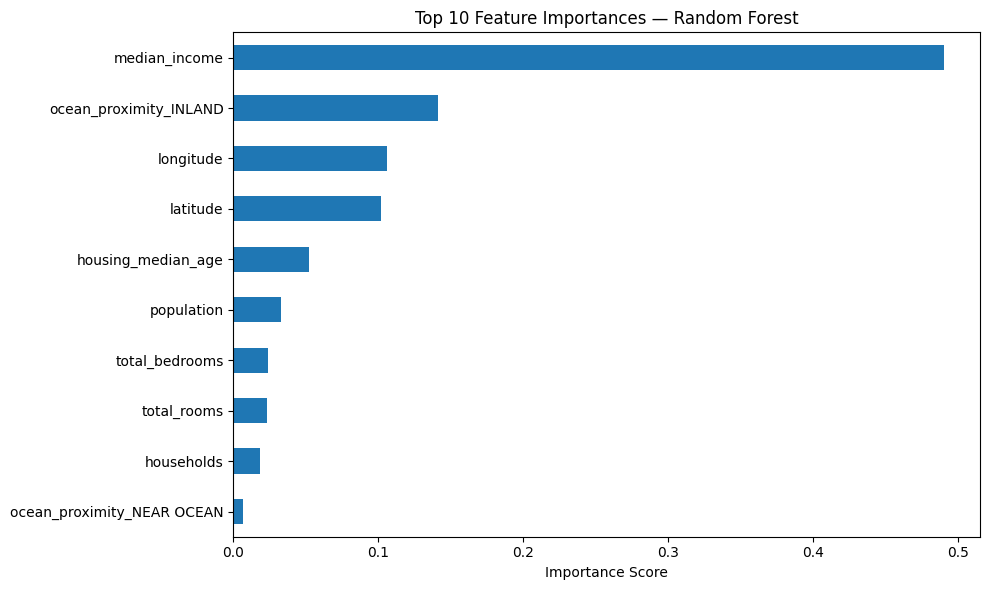

In [48]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
 
print("Top 10 Feature Importances:")
print(feature_importance.head(10).round(4))
 
feature_importance.head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
 

In [ ]:
#Task 6.2 — Why these features matter:
# - median_income    : Higher income = higher purchasing power → drives up prices
 # - latitude/longitude: Location is key; coastal/Bay Area properties cost more
 # - housing_median_age: Newer properties may be priced higher; older ones cheaper
  #- total_rooms/bedrooms: Larger homes command higher prices
  #- population/households: Dense areas often correlate with higher demand and prices


In [27]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Task 7.1 — Tunable hyperparameters are listed in comments:
# Linear Regression : fit_intercept, Ridge/Lasso alpha
# Decision Tree     : max_depth, min_samples_split, min_samples_leaf, criterion
# Random Forest     : n_estimators, max_depth, min_samples_split, max_features

In [28]:
# Task 7.2 — Manual Tuning
print("Manual Tuning — Decision Tree max_depth:")
for depth in [3, 5, 10, 15, None]:
    m = DecisionTreeRegressor(max_depth=depth, random_state=42)
    m.fit(X_train_scaled, y_train)
    p = m.predict(X_test_scaled)
    print(f"  max_depth={str(depth):5s}  RMSE={np.sqrt(mean_squared_error(y_test,p)):,.0f}  R2={r2_score(y_test,p):.4f}")


Manual Tuning — Decision Tree max_depth:
  max_depth=3      RMSE=76,813  R2=0.5497
  max_depth=5      RMSE=71,453  R2=0.6104
  max_depth=10     RMSE=61,280  R2=0.7134
  max_depth=15     RMSE=66,519  R2=0.6623
  max_depth=None   RMSE=69,079  R2=0.6358


In [36]:
# Task 7.2 — GridSearchCV
param_grid = {"n_estimators": [50, 100], "max_depth": [10, 20, None], "min_samples_split": [2, 5]}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring="r2", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"GridSearchCV Best Params: {grid_search.best_params_}")
print(f"GridSearchCV Best R2:     {grid_search.best_score_:.4f}")

GridSearchCV Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
GridSearchCV Best R2:     0.8122


In [35]:
# Task 7.2 — RandomizedSearchCV
param_dist = {"n_estimators": randint(50, 200), "max_depth": [5, 10, 20, None],
              "min_samples_split": randint(2, 10), "max_features": ["sqrt", "log2"]}
random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist,
                                   n_iter=20, cv=3, scoring="r2", n_jobs=-1, random_state=42)
random_search.fit(X_train_scaled, y_train)
print(f"RandomizedSearchCV Best Params: {random_search.best_params_}")
print(f"RandomizedSearchCV Best R2:     {random_search.best_score_:.4f}")

RandomizedSearchCV Best Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 199}
RandomizedSearchCV Best R2:     0.8086


In [31]:
# Task 7.3 — K-Fold Cross Validation (K=5)
print("5-Fold Cross Validation:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in [("Linear Regression", LinearRegression()),
                    ("Decision Tree",     DecisionTreeRegressor(random_state=42)),
                    ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=42))]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    print(f"  {name:25s}  Mean R2={scores.mean():.4f}  Std={scores.std():.4f}")


5-Fold Cross Validation:
  Linear Regression          Mean R2=0.6477  Std=0.0132
  Decision Tree              Mean R2=0.6318  Std=0.0119
  Random Forest              Mean R2=0.8172  Std=0.0055


In [33]:
y_pred_tuned = grid_search.best_estimator_.predict(X_test_scaled)
print("Tuned vs Untuned Comparison:")
for name, pred in [("RF Untuned", y_pred_rf), ("RF GridSearch Tuned", y_pred_tuned)]:
    print(f"  {name:25s}  RMSE={np.sqrt(mean_squared_error(y_test,pred)):,.0f}  R2={r2_score(y_test,pred):.4f}")


Tuned vs Untuned Comparison:
  RF Untuned                 RMSE=48,942  R2=0.8172
  RF GridSearch Tuned        RMSE=48,942  R2=0.8172


In [34]:
"""
Task 7.5 — Practical Interpretation:
  - median_income dominates (~49% importance): income = purchasing power = price driver
  - latitude/longitude: Bay Area & coastal blocks command large premiums
  - ocean_proximity_INLAND: strong negative signal — inland = cheaper
  - This model can be used for automated property valuation (AVM),
    mortgage assessments, and identifying underpriced listings.
"""

'\nTask 7.5 — Practical Interpretation:\n  - median_income dominates (~49% importance): income = purchasing power = price driver\n  - latitude/longitude: Bay Area & coastal blocks command large premiums\n  - ocean_proximity_INLAND: strong negative signal — inland = cheaper\n  - This model can be used for automated property valuation (AVM),\n    mortgage assessments, and identifying underpriced listings.\n'